# 3.线性神经网络

回归（regression）是能为一个或多个自变量与因变量之间关系建模的一类方法。在自然科学和社会科学领域，回归经常用来表示输入和输出之间的关系。

## 3.1 线性回归（linear regression）

### 术语

- 训练数据集（training data set）或训练集（training set）
- 数据集的每行数据称为样本（sample），也可以称为数据点（datapoint）或数据样本（data instance）
- 把试图预测的目标称为标签（label）或目标（target）
- 预测所依据的自变量称为特征（feature）或协变量（covariate）

通常，我们使用n来表示数据集中的样本数。
对索引为i的样本，其输入表示为$x^{(i)}=[x^{(i)}_1,x^{(i)}_2 ]^⊤$，其对应的标签是$y^{(i)}$。

### 线性模型
线性假设是指目标（房屋价格）可以表示为特征（面积和房龄）的加权和，如下面的式子：

$price = w_{area} · area + w_{age} · age + b$ 

$w_{area}$和$w_{age}$ 称为权重（weight），权重决定了每个特征对我们预测值的影响。b称为偏置（bias）、偏移量（offset）或截距（intercept）。偏置是指当所有特征都取值为0时，预测值应该为多少。 
如果没有偏置项，我们模型的表达能力将受到限制。 
严格来说，上面的式子是输入特征的一个仿射变换（affine transformation）。仿射变换的特点是通过加权和对特征进行线性变换（linear transformation），并通过偏置项来进行平移（translation）。

### 损失函数

在我们开始考虑如何用模型拟合（fit）数据之前，我们需要确定一个拟合程度的度量。 损失函数（loss function）能够量化目标的实际值与预测值之间的差距。  
通常我们会选择非负数作为损失，且数值越小表示损失越小，完美预测时的损失为0。 回归问题中最常用的损失函数是平方误差函数。  

由于平方误差函数中的二次方项， 估计值和观测值之间较大的差异将导致更大的损失。   

为了度量模型在整个数据集上的质量，我们需计算在训练集n个样本上的损失均值（也等价于求和）。


在训练模型时，我们希望寻找一组参数（$w^*$, $b^*$）， 这组参数能最小化在所有训练样本上的总损失。

#### 解析解
线性回归刚好是一个很简单的优化问题。 与我们将在本书中所讲到的其他大部分模型不同，线性回归的解可以用一个公式简单地表达出来， 这类解叫作解析解（analytical solution）。  


#### 随机梯度下降
即使在我们无法得到解析解的情况下，我们仍然可以有效地训练模型。 在许多任务上，那些难以优化的模型效果要更好。 因此，弄清楚如何训练这些难以优化的模型是非常重要的。  
一种名为梯度下降（gradient descent）的方法， 这种方法几乎可以优化所有深度学习模型。 它通过不断地在损失函数递减的方向上更新参数来降低误差。  
梯度下降最简单的用法是计算损失函数（数据集中所有样本的损失均值） 关于模型参数的导数（在这里也可以称为梯度）。 但实际中的执行可能会非常慢：因为在每一次更新参数之前，我们必须遍历整个数据集。 因此，我们通常会在每次需要计算更新的时候随机抽取一小批样本， 这种变体叫做小批量随机梯度下降（minibatch stochastic gradient descent）。


批量大小和学习率的值通常是手动预先指定，而不是通过模型训练得到的。   
这些可以调整但不在训练过程中更新的参数称为超参数（hyperparameter）。   

调参（hyperparameter tuning）是选择超参数的过程。  

超参数通常是我们根据训练迭代结果来调整的， 而训练迭代结果是在独立的验证数据集（validation dataset）上评估得到的。

#### 用模型进行预测
给定特征估计目标的过程通常称为预测（prediction）

#### 矢量化加速
在训练我们的模型时，我们经常希望能够同时处理整个小批量的样本。 为了实现这一点，需要我们对计算进行矢量化， 从而利用线性代数库，而不是在Python中编写开销高昂的for循环。

In [8]:
%matplotlib inline
import math
import time
import numpy as np
import torch
from d2l import torch as d2l

In [24]:
n = 10000  # 样本数
a = torch.ones([n]) 
b = torch.ones([n]) 

In [25]:
class Timer: #@save
    """记录多次运行时间"""
    def __init__(self):
        self.times = []
        self.start()

    def start(self):
        """启动计时器"""
        self.tik = time.time()

    def stop(self):
        """停止计时器并将时间记录在times中"""
        self.times.append(time.time() - self.tik)
        return self.times[-1]

    def avg(self):
        """返回平均时间"""
        return sum(self.times) / len(self.times)

    def sum(self):
        """返回总时间"""
        return sum(self.times)

    def cumsum(self):
        """返回累计时间"""
        return np.array(self.times).cumsum().tolist()

现在我们可以对工作负载进行基准测试。

In [35]:
c = torch.zeros(n) # for循环的开销
timer = Timer()
for i in range(n):
    c[i] = a[i] + b[i]
f'{timer.stop():.5f} sec'

'0.05697 sec'

In [ ]:
timer.start()
d = a + b  #  矢量化代码通常会带来数量级的加速。
f'{timer.stop():.5f} sec'

'0.00064 sec'

#### 正态分布与平方损失

正态分布和线性回归之间的关系很密切。 正态分布（normal distribution），也称为高斯分布（Gaussian distribution）

In [43]:
def normal(x, mu, sigma):
    p = 1 / math.sqrt(2 * math.pi * sigma**2)
    return p * np.exp(-0.5 / sigma**2 * (x - mu)**2)

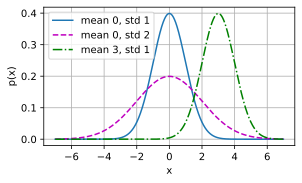

In [44]:
x = np.arange(-7, 7, 0.01)
params = [(0, 1), (0, 2), (3, 1)]
d2l.plot(x, [normal(x, mu, sigma) for mu, sigma in params], xlabel='x', ylabel='p(x)', figsize=(4.5, 2.5), legend=[f'mean {mu}, std {sigma}' for mu, sigma in params])

改变均值会产生沿x轴的偏移，增加方差将会分散分布、降低其峰值。

注：  
在线性网络（尤其是线性回归）中，正态分布负责描述数据中的噪声，最大似然估计负责确定模型参数。它们共同解释了：为什么线性回归通常使用均方误差作为损失函数。

### 3.1.4 从线性回归到深度网络

输入层中的输入数（或称为特征维度，feature dimensionality）为d。   
网络的输出为 $O_1$，因此输出层中的输出数是1。   
需要注意的是，输入值都是已经给定的，并且只有一个**计算**神经元。  
由于模型重点在发生计算的地方，所以通常我们在计算层数时不考虑输入层。  
也就是说，线性回归模型神经网络的层数为1。  
我们可以将线性回归模型视为仅由单个人工神经元组成的神经网络，或称为单层神经网络。

对于线性回归，每个输入都与每个输出（在本例中只有一个输出）相连， 我们将这种变换称为全连接层（fully-connected layer）或称为稠密层（dense layer）。

#### 生物学

线性回归发明的时间（1795年）早于计算神经科学，所以将线性回归描述为神经网络似乎不合适。  

当今大多数深度学习的研究几乎没有直接从神经科学中获得灵感。 

如今在深度学习中的灵感同样或更多地来自数学、统计学和计算机科学。

## 3.2 线性回归的从零开始实现

在这一节中，我们将从零开始实现整个方法， 包括数据流水线、模型、损失函数和小批量随机梯度下降优化器。 

In [9]:
%matplotlib inline
import random
import torch
from d2l import torch as d2l


f:\code\condaEnv\py310\lib\site-packages\requests\__init__.py:86: RequestsDependencyWarning: Unable to find acceptable character detection dependency (chardet or charset_normalizer).
  warnings.warn(


### 3.2.1  生成数据集

In [11]:
def synthetic_data(w, b, num_examples): #@save
    """生成y = Xw + b + 噪声"""
    X = torch.normal(0, 1, (num_examples, len(w)))
    y = torch.matmul(X, w) + b
    y += torch.normal(0, 0.01, y.shape)
    return X, y.reshape((-1, 1))

true_w = torch.tensor([2, -3.4])
true_b = 4.2
features, labels = synthetic_data(true_w, true_b, 1000)

In [12]:
print('features:', features[0], '\nlabel:', labels[0])

features: tensor([ 1.1936, -0.5554]) 
label: tensor([8.4866])


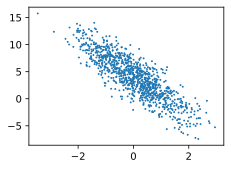

In [13]:
d2l.set_figsize()
d2l.plt.scatter(features[:, 1].detach().numpy(), labels.detach().numpy(), 1);

### 3.2.2. 读取数据集

In [22]:
def data_iter(batch_size, features, labels):
    print('features:', features[0], '\nlabel:', labels[0])
    num_examples = len(features)
    indices = list(range(num_examples))
    # 这些样本是随机读取的， 没有特定的顺序
    random.shuffle(indices)
    for i in range(0, num_examples, batch_size):
        batch_indices = torch.tensor(indices[i: min(i + batch_size, num_examples)])
        yield features[batch_indices], labels[batch_indices]

In [23]:
batch_size = 10

for X, y in data_iter(batch_size, features, labels):
    print(X, '\n', y)
    break

features: tensor([ 1.1936, -0.5554]) 
label: tensor([8.4866])
tensor([[-9.8590e-01,  1.0938e+00],
        [ 1.3838e+00,  7.3548e-01],
        [ 4.0244e-01,  1.9327e+00],
        [-1.4720e-02, -1.4556e-01],
        [-3.2774e-01, -6.5741e-01],
        [ 2.8861e+00,  1.2184e+00],
        [ 1.5575e-01, -1.2663e-03],
        [-8.0668e-01, -2.8762e+00],
        [ 3.5821e-02,  6.2883e-01],
        [-4.0932e-01,  2.9325e-01]]) 
 tensor([[-1.4951],
        [ 4.4806],
        [-1.5683],
        [ 4.6754],
        [ 5.7822],
        [ 5.8340],
        [ 4.5073],
        [12.3725],
        [ 2.1482],
        [ 2.3986]])


In [24]:
#检查数据的整体情况
print(features.mean(dim=0))
print(features.std(dim=0))
print((features < 0).float().mean(dim=0))

tensor([-0.0420,  0.0361])
tensor([1.0306, 1.0122])
tensor([0.5060, 0.4860])


开始用小批量随机梯度下降优化我们的模型参数之前， 我们需要先有一些参数。 在下面的代码中，我们通过从均值为0、标准差为0.01的正态分布中采样随机数来初始化权重， 并将偏置初始化为0。

In [25]:
w = torch.normal(0, 0.01, size=(2,1), requires_grad=True)
b = torch.zeros(1, requires_grad=True)

在初始化参数之后，我们的任务是更新这些参数，直到这些参数足够拟合我们的数据。 每次更新都需要计算损失函数关于模型参数的梯度。  
有了这个梯度，我们就可以向减小损失的方向更新每个参数。

### 3.2.4. 定义模型

In [27]:
def linreg(X, w, b):  #@save
    """线性回归模型"""
    return torch.matmul(X, w) + b

### 3.2.5. 定义损失函数

因为需要计算损失函数的梯度，所以我们应该先定义损失函数。 这里我们使用 3.1节中描述的平方损失函数。 在实现中，我们需要将真实值y的形状转换为和预测值y_hat的形状相同。

In [28]:
def squared_loss(y_hat, y):  #@save
    """均方损失"""
    return (y_hat - y.reshape(y_hat.shape)) ** 2 / 2

### 3.2.6. 定义优化算法

正如我们在 3.1节中讨论的，线性回归有解析解。 尽管线性回归有解析解，但本书中的其他模型却没有。 这里我们介绍小批量随机梯度下降。

在每一步中，使用从数据集中随机抽取的一个小批量，然后根据参数计算损失的梯度。 接下来，朝着减少损失的方向更新我们的参数。 下面的函数实现小批量随机梯度下降更新。 该函数接受模型参数集合、学习速率和批量大小作为输入。每 一步更新的大小由学习速率lr决定。 因为我们计算的损失是一个批量样本的总和，所以我们用批量大小（batch_size） 来规范化步长，这样步长大小就不会取决于我们对批量大小的选择。

In [29]:
def sgd(params, lr, batch_size):  #@save
    """小批量随机梯度下降"""
    with torch.no_grad():
        for param in params:
            param -= lr * param.grad / batch_size
            param.grad.zero_()

### 3.2.7. 训练

现在我们已经准备好了模型训练所有需要的要素，可以实现主要的训练过程部分了。  
理解这段代码至关重要，因为从事深度学习后， 相同的训练过程几乎一遍又一遍地出现。 在每次迭代中，我们读取一小批量训练样本，并通过我们的模型来获得一组预测。 计算完损失后，我们开始反向传播，存储每个参数的梯度。 最后，我们调用优化算法sgd来更新模型参数。

在每个迭代周期（epoch）中，我们使用data_iter函数遍历整个数据集， 并将训练数据集中所有样本都使用一次（假设样本数能够被批量大小整除）。  
这里的迭代周期个数num_epochs和学习率lr都是超参数，分别设为3和0.03。   
设置超参数很棘手，需要通过反复试验进行调整。 我们现在忽略这些细节，以后会在 11节中详细介绍。

In [ ]:
lr = 0.03
num_epochs = 3
net = linreg
loss = squared_loss

for epoch in range(num_epochs):
    for X, y in data_iter(batch_size, features, labels):
        l = loss(net(X, w, b), y)  # X和y的小批量损失
        # 因为l形状是(batch_size,1)，而不是一个标量。l中的所有元素被加到一起，
        # 并以此计算关于[w,b]的梯度
        l.sum().backward()
        #sgd([w, b], lr, batch_size)  # 使用随机梯度下降算法参数的梯度更新参数
        sgd([w, b], lr, X.shape[0]) #最后一个批次可能不足 batch_size，这是更严谨的写法
    with torch.no_grad():
        train_l = loss(net(features, w, b), labels)
        print(f'epoch {epoch + 1}, loss {float(train_l.mean()):f}')

features: tensor([ 1.1936, -0.5554]) 
label: tensor([8.4866])
epoch 1, loss 0.046343
features: tensor([ 1.1936, -0.5554]) 
label: tensor([8.4866])
epoch 2, loss 0.000183
features: tensor([ 1.1936, -0.5554]) 
label: tensor([8.4866])
epoch 3, loss 0.000050
